In [73]:
#Import Libraries
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import kruskal, mannwhitneyu, spearmanr, skew

# ML preprocessing
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [74]:
#Download Data
data = pd.read_excel("../data/ctech projects (CA).xlsx")

print("Shape:", data.shape)
data.head()


Shape: (46608, 30)


,Flex Project UUID,Confirmation Year,Handler Region,Product Group,Product Type,Product Type Code,Product Type Segment,Industry Name,Industry Code,Service Line Code,Service Line Name,Service Detail,Service Program,Service Catalog Category,Service Catalog Item Number,Service Catalog Segment,Service Catalog Sub Category,CCN,Ship to Customer Region,Has Test Task Flag,Ship to Account Number,Flex Standards,Standard Count,Avg Scoped Hours Engineer,Avg Scoped Hours Lab,Flex Project Count,Total Scoped Hours,Actual Eng Hours,Actual Lab Hours,Test Count
0,00006a1e-851e-416b-b3ef-6185b8d8c134,2025,Americas,NaN,"Networking Devices (Router, Bridge, Hub, Modem...",UL_SERVICE,NaN,High Tech,111,102,Safety Certification Services,UL and cUL Mark Bundle (Revision of existing c...,Alternate Construction,PRDC,30056282-CPQ,CRT,North America Market Services,AZOT,Americas,No,1459815,"UL 62368-1 AUDIO/VIDEO, INFORMATION AND COMMUN...",2,7.0,0.00,1,7.00,8.15,0.00,0
1,0000abd2-02b6-4fe2-9c15-f023218ff27c,2025,APAC,Display Devices,Display LED/LCD TV/Monitor (< 20 in.),UL_SERVICE,NaN,High Tech,111,797,Consumer EMC Testing,EMC Customer Directed Testing,Other EMC Services,EMCT,30055064-CPQ,TST,Global Market Services,AAAD,Asia,Yes,2983469,NaN,0,1.0,6.00,1,7.00,0.00,6.00,0
2,0002eafc-ac66-4797-8a1e-e6bfe890c118,2025,EMEA,NaN,"Networking Devices (Router, Bridge, Hub, Modem...",UL_SERVICE,NaN,High Tech,111,797,Consumer EMC Testing,EN 301 489-1; EN 301 489-17,EMC-RED,EMCT,30055075-CPQ,TST,Europe Market Services,NaN,EMEA,Yes,244675,NaN,0,19.0,63.75,1,82.75,12.00,88.25,0
3,0003ad27-5a88-4bf4-91aa-0f2477cf71aa,2025,APAC,Patient Monitor,Non-Invasive Blood Pressure (NIBP),UL_SERVICE,NaN,Health Sciences,701,789,Consumer Wireless Regulatory Testing,EN 300 328,Wireless Regulatory,WRTG,30055268-CPQ,TST,Europe Market Services,NaN,Asia,Yes,730212,NaN,0,24.0,8.00,1,32.00,3.00,6.50,0
4,0005bc78-184e-4633-9440-d9f8b2596feb,2025,APAC,Rechargeable,"Battery Pack (Lithium, Rechargeable)",UL_SERVICE,NaN,High Tech,111,102,Safety Certification Services,CB Test Report and Certificate (New Certificat...,New Construction,PRDC,30054080-CPQ,CRT,Global Market Services,AAAE,Asia,Yes,579813,"IEC 62133-2, Secondary cells and batteries con...",1,16.0,16.00,1,32.00,11.50,9.00,4


In [75]:
#List column Name in a python list
data.columns.tolist()

['Flex Project UUID',
 'Confirmation Year',
 'Handler Region',
 'Product Group',
 'Product Type',
 'Product Type Code',
 'Product Type Segment',
 'Industry Name',
 'Industry Code',
 'Service Line Code',
 'Service Line Name',
 'Service Detail',
 'Service Program',
 'Service Catalog Category',
 'Service Catalog Item Number',
 'Service Catalog Segment',
 'Service Catalog Sub Category',
 'CCN',
 'Ship to Customer Region',
 'Has Test Task Flag',
 'Ship to Account Number',
 'Flex Standards',
 'Standard Count',
 'Avg Scoped Hours Engineer',
 'Avg Scoped Hours Lab',
 'Flex Project Count',
 'Total Scoped Hours',
 'Actual Eng Hours',
 'Actual Lab Hours',
 'Test Count']

In [76]:
#Check how many missing values each column has and the %
missing_summary = pd.DataFrame({
    "Missing_Count": data.isna().sum(),
    "Missing_Percent": data.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percent",
    ascending=False
)

missing_summary[missing_summary["Missing_Count"] > 0]


,Missing_Count,Missing_Percent
Product Type Segment,45377,97.358823
Flex Standards,33323,71.496310
Avg Scoped Hours Lab,19239,41.278321
Product Group,16853,36.159028
CCN,12671,27.186320
Avg Scoped Hours Engineer,3328,7.140405
Actual Lab Hours,684,1.467559
Actual Eng Hours,684,1.467559
Service Program,576,1.235839
Service Detail,544,1.167182


In [77]:
#Check for duplicates
print("Total Rows:", len(data))
print("Duplicate Rows:", data.duplicated().sum())

Total Rows: 46608
Duplicate Rows: 0


In [78]:
#Check Data types

data.dtypes

Flex Project UUID                   str
Confirmation Year                   str
Handler Region                      str
Product Group                       str
Product Type                        str
Product Type Code                   str
Product Type Segment            float64
Industry Name                       str
Industry Code                       str
Service Line Code                   str
Service Line Name                   str
Service Detail                      str
Service Program                     str
Service Catalog Category            str
Service Catalog Item Number         str
Service Catalog Segment             str
Service Catalog Sub Category        str
CCN                                 str
Ship to Customer Region             str
Has Test Task Flag                  str
Ship to Account Number            int64
Flex Standards                      str
Standard Count                    int64
Avg Scoped Hours Engineer       float64
Avg Scoped Hours Lab            float64


In [79]:
#Summary Stats
data["Actual Eng Hours"].describe()

count    45924.000000
mean        12.594231
std         19.923312
min          0.000000
25%          3.250000
50%          7.500000
75%         15.042500
max        971.650000
Name: Actual Eng Hours, dtype: float64

12.537138657926373


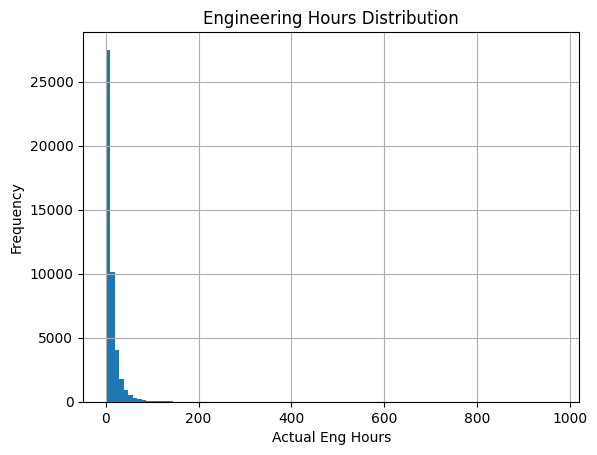

In [80]:
print(skew(data["Actual Eng Hours"].dropna()))

data["Actual Eng Hours"].hist(bins=100)

plt.title("Engineering Hours Distribution")
plt.xlabel("Actual Eng Hours")
plt.ylabel("Frequency")

plt.show()


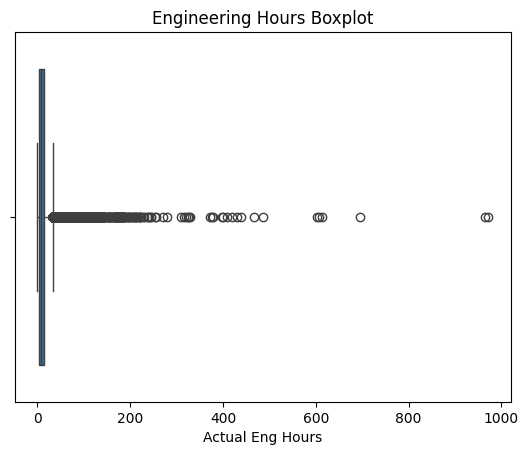

In [81]:
#Boxplot for Outliers

sns.boxplot(x=data["Actual Eng Hours"])

plt.title("Engineering Hours Boxplot")
plt.show()


0.15548819843091594


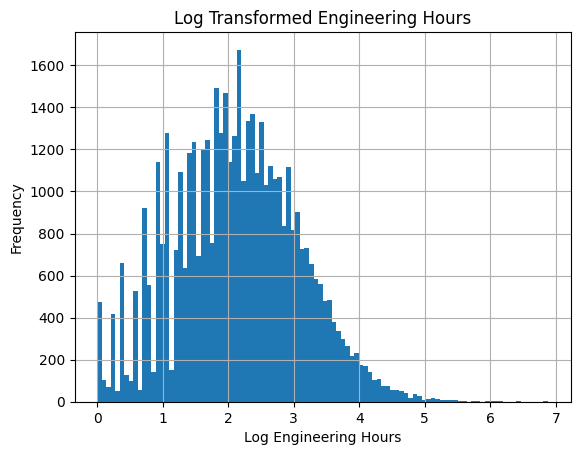

In [82]:
#test log transformation 
data["Log_Eng_Hours"] = np.log1p(data["Actual Eng Hours"])

print(skew(data["Log_Eng_Hours"].dropna()))


#then visualize it

data["Log_Eng_Hours"].hist(bins=100)

plt.title("Log Transformed Engineering Hours")
plt.xlabel("Log Engineering Hours")
plt.ylabel("Frequency")

plt.show()


In [83]:
#We are trying to see if region affects eng hours, and do diff regions behave differently. 
#count: how many projects belong to this region
#mean: What is the avg engineering hours for this region
#median: What is the middle eng hours value
#std: How spread out are the hours (if al projects are similar low std, if they vary highly high std)

region_summary = data.groupby("Handler Region")["Actual Eng Hours"].agg([
    "count",
    "mean",
    "median",
    "std"
]).sort_values(by="mean", ascending=False)

print(region_summary)


                count       mean  median        std
Handler Region                                     
Americas         5387  16.455630    9.85  28.307891
APAC            37840  12.118832    7.00  18.699196
EMEA             2697  11.551494    6.60  14.793483


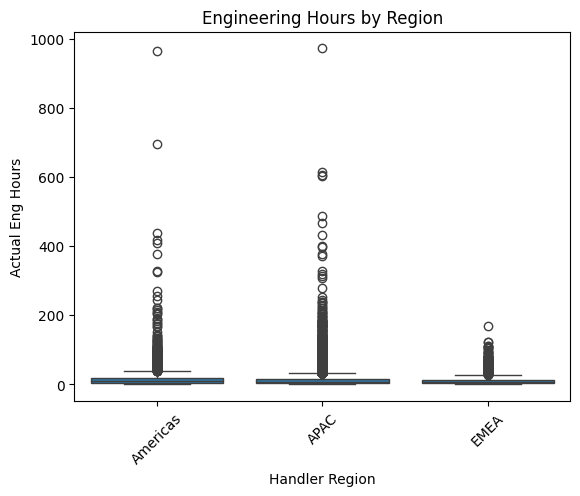

In [84]:
#Region Boxplot
sns.boxplot(
    data=data,
    x="Handler Region",
    y="Actual Eng Hours"
)

plt.xticks(rotation=45)
plt.title("Engineering Hours by Region")
plt.show()


In [85]:
#CCN Stats
ccn_counts = data ["CCN"].value_counts().reset_index()
ccn_counts.columns = ["CCN", "frequency"]
print(ccn_counts.to_string())

       CCN  frequency
0     AZOT       6641
1     AAAE       4409
2     ENVP       3726
3     AAAU       2410
4    AZOT2       1874
5    ZPMV2       1678
6     AAAD       1666
7     QQJQ       1574
8    QQJQ2       1560
9     EMCN        848
10    AAAL        843
11   BBCV2        531
12   BBFS2        508
13    AACT        507
14   ZPXK2        420
15   QMTS2        418
16    NWGQ        349
17    DKYT        290
18   BBGA2        243
19    AALC        190
20    BBFS        156
21   CTIA2        154
22    AAGS        139
23   QMJU2        130
24   QQGQ2        125
25   BBCA2        115
26    DKYA        107
27    AANI        100
28    NWIN         97
29    QGNS         95
30   BBTG2         94
31    DUXR         85
32    DKYK         81
33    DAPA         77
34   ZPVI2         66
35   FPPT2         65
36    JPST         58
37   BBTM2         57
38   FPQU2         57
39    IYNW         51
40    EMCA         47
41   NWGQ2         47
42   QGNS2         40
43    QPQY         40
44    QQGQ

In [86]:
#Top ten most frequent CCNs out of the 214 in our dataset
top_10_ccns = data["CCN"].value_counts().head(10).index

top_ccn_data = data[data["CCN"].isin(top_10_ccns)]

CCN_summary = top_ccn_data.groupby("CCN")["Actual Eng Hours"].agg([
    "count",
    "mean",
    "median",
    "std"
]).sort_values(by="mean", ascending=False)

print(CCN_summary)


       count       mean  median        std
CCN                                       
QQJQ2   1557  19.420886  15.500  16.945089
AZOT    6624  15.917787  10.250  21.433121
QQJQ    1569  14.570153  12.500  12.735773
AZOT2   1870  13.354936  10.000  12.079581
ZPMV2   1678  12.409434  10.175   8.724725
AAAU    2392  11.380811   7.000  14.370115
AAAD    1500  10.123420   3.250  18.545434
AAAE    4371   7.415758   3.000  11.315417
ENVP    3717   6.238472   5.300   4.758483
EMCN     812   5.923030   1.400  15.796880


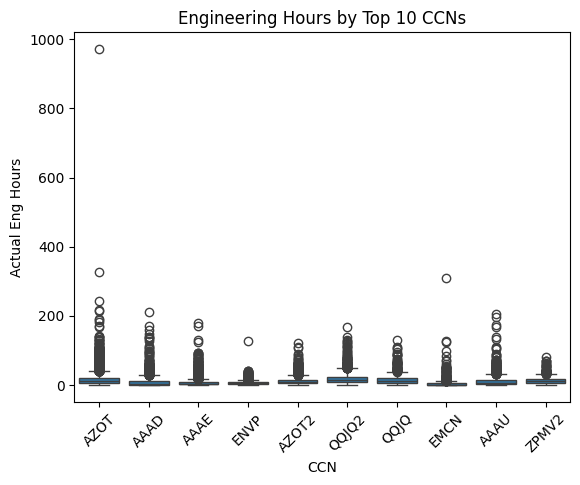

In [87]:
#CCN Boxplot
sns.boxplot(
    data=top_ccn_data,
    x="CCN",
    y="Actual Eng Hours"
)

plt.xticks(rotation=45)

plt.title("Engineering Hours by Top 10 CCNs")

plt.show()


In [88]:
TARGET = "Actual Eng Hours"

cat_cols = data.select_dtypes(include=["object"]).columns

for col in cat_cols:
    if col in ["Flex Project UUID"]:
        continue

    print("\n" + "="*80)
    print(f"Column: {col}")
    print("="*80)

    summary = data.groupby(col)[TARGET].agg([
        "count",
        "mean",
        "median",
        "std"
    ])

    # only keep categories with at least 50 projects
    summary = summary[summary["count"] >= 50]

    summary = summary.sort_values(by="mean", ascending=False)

    print(summary.head(15))



Column: Confirmation Year
                   count       mean  median         std
Confirmation Year                                      
2025, 2026            79  45.919873   27.70  112.024887
2025               38741  13.196341    7.75   20.483271
2026                7104   8.940083    6.00   10.607141

Column: Handler Region
                count       mean  median        std
Handler Region                                     
Americas         5387  16.455630    9.85  28.307891
APAC            37840  12.118832    7.00  18.699196
EMEA             2697  11.551494    6.60  14.793483

Column: Product Group
                               count       mean  median         std
Product Group                                                      
Automotive                        72  31.335278   2.400  104.619289
Other Devices                    375  22.489173  13.500   52.970810
Cabinets                          72  21.397083  10.750   24.200261
Audio/Video Equipment             66  17.41772

In [89]:
#correlation analysis 

numeric_cols = data.select_dtypes(include=[np.number])

corrs = numeric_cols.corr()["Actual Eng Hours"].sort_values(ascending=False)

corrs


Actual Eng Hours             1.000000
Log_Eng_Hours                0.703673
Avg Scoped Hours Engineer    0.546462
Total Scoped Hours           0.523904
Avg Scoped Hours Lab         0.359143
Actual Lab Hours             0.306499
Standard Count               0.110391
Test Count                   0.099997
Product Type Segment         0.067090
Ship to Account Number       0.008171
Flex Project Count                NaN
Name: Actual Eng Hours, dtype: float64

In [90]:
TARGET = "Actual Eng Hours"

num_cols = data.select_dtypes(include=[np.number]).columns

num_cols = [col for col in num_cols if col != TARGET]

for col in num_cols:
    print("\n" + "="*80)
    print(f"Column: {col}")
    print("="*80)

    print(data[col].describe())

    corr = data[[col, TARGET]].corr().iloc[0,1]
    print(f"Correlation with {TARGET}: {corr}")



Column: Product Type Segment
count    1231.000000
mean      182.285134
std       199.956505
min       111.000000
25%       111.000000
50%       111.000000
75%       111.000000
max       760.000000
Name: Product Type Segment, dtype: float64
Correlation with Actual Eng Hours: 0.0670904888090917

Column: Ship to Account Number
count    4.660800e+04
mean     1.077678e+06
std      1.214012e+06
min      2.153000e+03
25%      1.465215e+05
50%      5.895040e+05
75%      1.576540e+06
max      4.477781e+06
Name: Ship to Account Number, dtype: float64
Correlation with Actual Eng Hours: 0.008171413506016884

Column: Standard Count
count    46608.000000
mean         0.629227
std          1.328988
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         21.000000
Name: Standard Count, dtype: float64
Correlation with Actual Eng Hours: 0.11039098731448867

Column: Avg Scoped Hours Engineer
count    43280.000000
mean        18.024744
std         34.720892
min

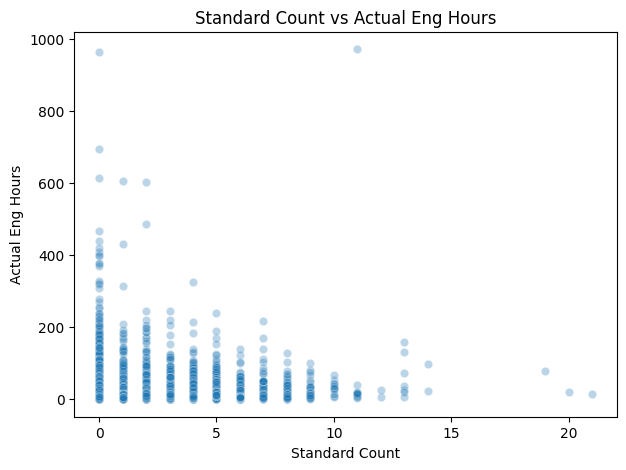

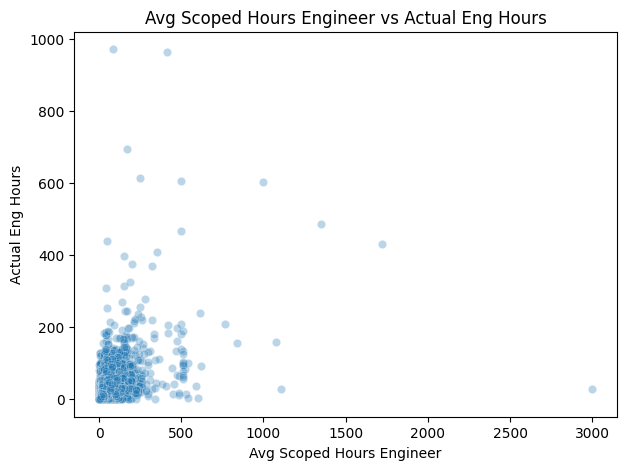

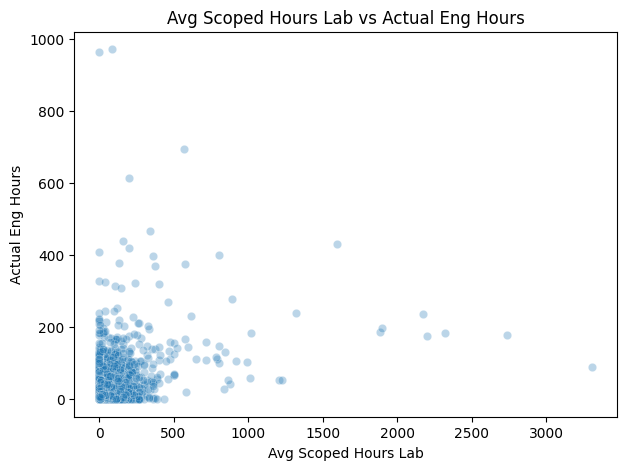

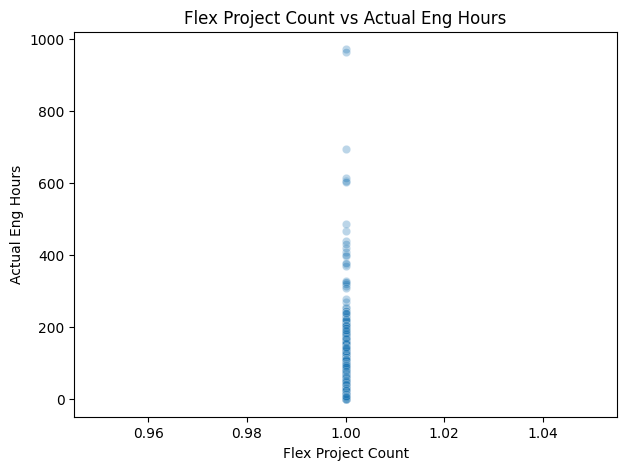

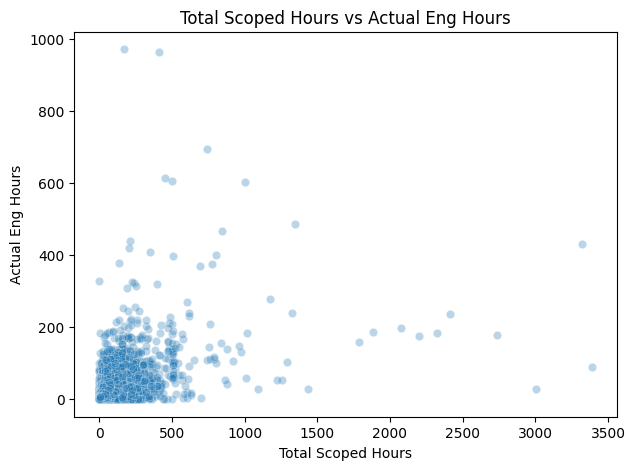

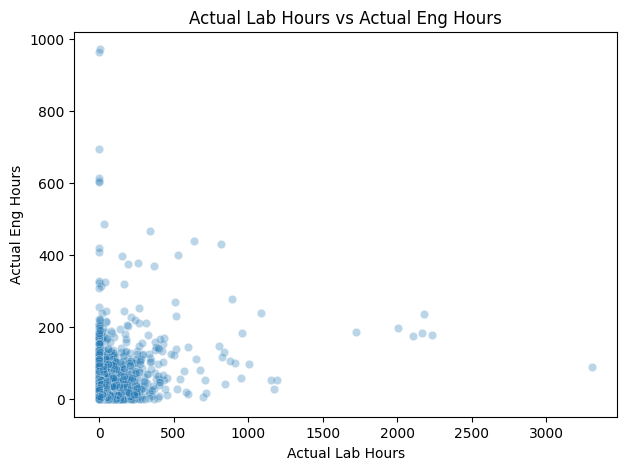

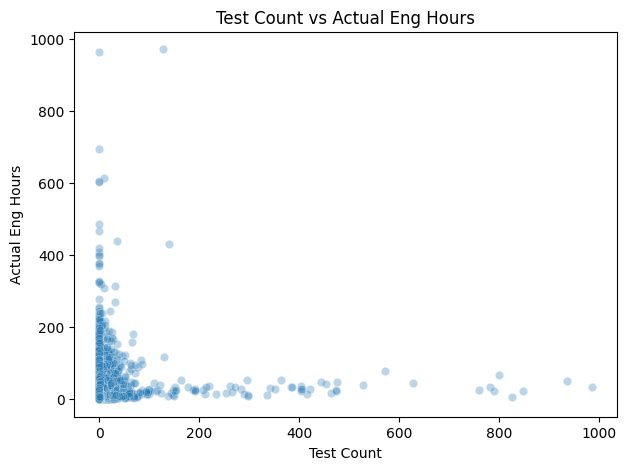

In [91]:
important_num_cols = [
    "Standard Count",
    "Avg Scoped Hours Engineer",
    "Avg Scoped Hours Lab",
    "Flex Project Count",
    "Total Scoped Hours",
    "Actual Lab Hours",
    "Test Count"
]

for col in important_num_cols:
    plt.figure(figsize=(7,5))
    
    sns.scatterplot(
        data=data,
        x=col,
        y=TARGET,
        alpha=0.3
    )
    
    plt.title(f"{col} vs {TARGET}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.show()


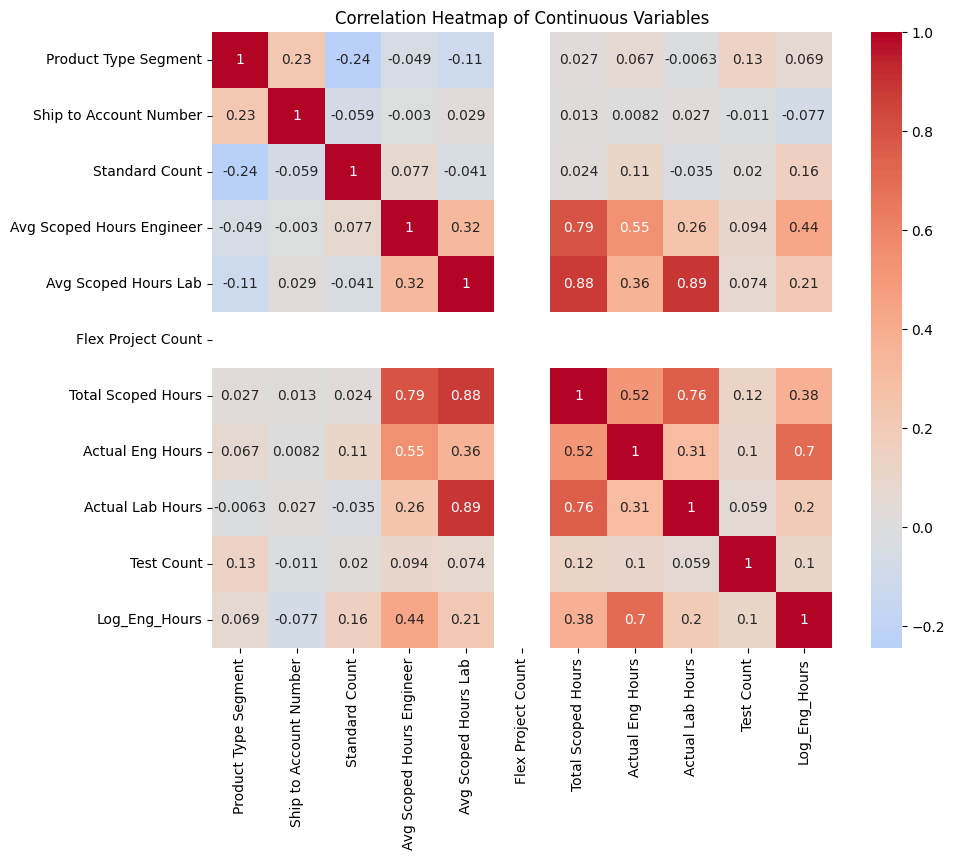

In [92]:
numeric_cols = data.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Continuous Variables")
plt.show()


In [93]:
#Check Categorical Cardinality
cat_cols = data.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(col, ":", data[col].nunique())


Flex Project UUID : 46608
Confirmation Year : 3
Handler Region : 3
Product Group : 218
Product Type : 785
Product Type Code : 10
Industry Name : 33
Industry Code : 33
Service Line Code : 167
Service Line Name : 167
Service Detail : 2440
Service Program : 566
Service Catalog Category : 76
Service Catalog Item Number : 2600
Service Catalog Segment : 22
Service Catalog Sub Category : 359
CCN : 214
Ship to Customer Region : 3
Has Test Task Flag : 2
Flex Standards : 3451


In [94]:
# ============================================================
# ADVANCED EDA TESTS
# Spearman Correlation, Kruskal-Wallis, Mutual Information
# Target: Actual Engineering Hours
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kruskal
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression

TARGET = "Actual Eng Hours"

# Make a clean EDA copy
eda_df = data.copy()

# Convert target to numeric
eda_df[TARGET] = pd.to_numeric(eda_df[TARGET], errors="coerce")

# Remove rows where target is missing
eda_df = eda_df.dropna(subset=[TARGET])

print("EDA dataset shape after dropping missing target:", eda_df.shape)


EDA dataset shape after dropping missing target: (45924, 31)


In [109]:
#delete columns to not bias testing
TARGET = "Actual Eng Hours"

eda_df = data.copy()

eda_df[TARGET] = pd.to_numeric(eda_df[TARGET], errors="coerce")
eda_df = eda_df.dropna(subset=[TARGET])

remove_cols = [
    "Actual Lab Hours",
    "Avg Scoped Hours Engineer",
    "Avg Scoped Hours Lab",
    "Total Scoped Hours",
     "Log_Eng_Hours"
]

eda_df = eda_df.drop(columns=remove_cols, errors="ignore")

numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()

numeric_features = [
    col for col in numeric_cols
    if col != TARGET
]

print(eda_df.columns.tolist())


['Flex Project UUID', 'Confirmation Year', 'Handler Region', 'Product Group', 'Product Type', 'Product Type Code', 'Product Type Segment', 'Industry Name', 'Industry Code', 'Service Line Code', 'Service Line Name', 'Service Detail', 'Service Program', 'Service Catalog Category', 'Service Catalog Item Number', 'Service Catalog Segment', 'Service Catalog Sub Category', 'CCN', 'Ship to Customer Region', 'Has Test Task Flag', 'Ship to Account Number', 'Flex Standards', 'Standard Count', 'Flex Project Count', 'Actual Eng Hours', 'Test Count']


In [110]:
# ============================================================
# 1) SPEARMAN CORRELATION
# Continuous/numeric variables vs Actual Eng Hours
# ============================================================

numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from feature list
numeric_features = [col for col in numeric_cols if col != TARGET]

spearman_results = []

for col in numeric_features:
    temp = eda_df[[col, TARGET]].dropna()
    
    if temp[col].nunique() > 1:
        corr, p_value = spearmanr(temp[col], temp[TARGET])
        
        spearman_results.append({
            "Feature": col,
            "Spearman_Correlation": corr,
            "P_Value": p_value,
            "Abs_Correlation": abs(corr)
        })

spearman_df = pd.DataFrame(spearman_results)

spearman_df = spearman_df.sort_values(
    by="Abs_Correlation",
    ascending=False
)

print("Spearman Correlation Results:")
print(spearman_df)


Spearman Correlation Results:
                  Feature  Spearman_Correlation        P_Value  \
3              Test Count              0.311386   0.000000e+00   
2          Standard Count              0.130230  7.638715e-173   
1  Ship to Account Number             -0.076182   4.421090e-60   
0    Product Type Segment              0.049622   1.044160e-01   

   Abs_Correlation  
3         0.311386  
2         0.130230  
1         0.076182  
0         0.049622  


In [97]:
# ============================================================
# 2) KRUSKAL-WALLIS TEST
# Categorical variables vs Actual Eng Hours
# ============================================================

cat_cols = eda_df.select_dtypes(include=["object"]).columns.tolist()

# Remove obvious ID column
cat_cols = [col for col in cat_cols if col not in ["Flex Project UUID"]]

kruskal_results = []

for col in cat_cols:
    
    temp = eda_df[[col, TARGET]].dropna()
    
    # Only keep categories with at least 50 records
    valid_categories = temp[col].value_counts()
    valid_categories = valid_categories[valid_categories >= 50].index
    
    temp = temp[temp[col].isin(valid_categories)]
    
    groups = [
        group[TARGET].values
        for name, group in temp.groupby(col)
        if len(group) >= 50
    ]
    
    if len(groups) >= 2:
        stat, p_value = kruskal(*groups)
        
        kruskal_results.append({
            "Feature": col,
            "Kruskal_Statistic": stat,
            "P_Value": p_value,
            "Num_Categories_Tested": len(groups)
        })

kruskal_df = pd.DataFrame(kruskal_results)

kruskal_df = kruskal_df.sort_values(
    by="Kruskal_Statistic",
    ascending=False
)

print("Kruskal-Wallis Results:")
print(kruskal_df)


Kruskal-Wallis Results:
                         Feature  Kruskal_Statistic        P_Value  \
9                 Service Detail       13096.654918   0.000000e+00   
12   Service Catalog Item Number       13055.795441   0.000000e+00   
14  Service Catalog Sub Category        6877.194274   0.000000e+00   
10               Service Program        6709.746625   0.000000e+00   
15                           CCN        6607.911744   0.000000e+00   
8              Service Line Name        5774.312790   0.000000e+00   
7              Service Line Code        5774.312790   0.000000e+00   
11      Service Catalog Category        4169.796371   0.000000e+00   
3                   Product Type        3390.546479   0.000000e+00   
13       Service Catalog Segment        3133.728201   0.000000e+00   
18                Flex Standards        2407.228502   0.000000e+00   
2                  Product Group        1718.573894   0.000000e+00   
17            Has Test Task Flag        1272.634400  1.000458e-278

In [111]:
# ============================================================
# 3) MUTUAL INFORMATION
# Measures predictive signal between features and Actual Eng Hours
# ============================================================

mi_df = eda_df.copy()

# Drop obvious ID columns
drop_cols = [
    "Flex Project UUID"
]

mi_df = mi_df.drop(columns=drop_cols, errors="ignore")

# Separate target
y = mi_df[TARGET]

X = mi_df.drop(columns=[TARGET], errors="ignore")

# Encode categorical columns
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = X[col].fillna("Missing").astype(str)
    X[col] = LabelEncoder().fit_transform(X[col])

# Fill numeric missing values
X = X.fillna(0)

# Keep only numeric after encoding
X = X.select_dtypes(include=[np.number])

mi_scores = mutual_info_regression(
    X,
    y,
    random_state=42
)

mutual_info_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_scores
})

mutual_info_df = mutual_info_df.sort_values(
    by="MI_Score",
    ascending=False
)

print("Top Features by Mutual Information:")
print(mutual_info_df.head(25))


Top Features by Mutual Information:
                         Feature  MI_Score
13   Service Catalog Item Number  0.404040
10                Service Detail  0.398707
19        Ship to Account Number  0.252973
11               Service Program  0.222426
16                           CCN  0.213599
3                   Product Type  0.198689
15  Service Catalog Sub Category  0.172118
9              Service Line Name  0.169878
8              Service Line Code  0.163654
20                Flex Standards  0.130847
12      Service Catalog Category  0.119056
2                  Product Group  0.118196
23                    Test Count  0.075964
14       Service Catalog Segment  0.070733
18            Has Test Task Flag  0.056018
7                  Industry Code  0.036661
6                  Industry Name  0.035974
21                Standard Count  0.035060
17       Ship to Customer Region  0.027874
1                 Handler Region  0.023450
0              Confirmation Year  0.013801
4              Pro